# Land Use Predictor
The goal of this notebook is to try predict the land use in certain areas based on an sentinel data
The initial idea is to use openmaps data to label the areas and then use sentinel to train the model

### Select Area of Interest
Choose a city or region with varied land uses (e.g., London, Berlin)
### Download Data
Sentinel-2: Use sentinelsat to download imagery (e.g. cloud-free composites)
OSM: Use osmnx, geopandas, or Overpass API to download land use polygons
### Preprocess
Clip Sentinel-2 imagery to land use polygons
Resample imagery to uniform resolution (10m)
Match each image patch to its land use label from OSM
### Dataset Creation
Create a set of image tiles (e.g. 64x64 or 128x128 patches)
Label each tile based on majority land use from the OSM polygon it overlaps with
### Model
Use a simple CNN for classification (if doing tile-based)
Alternatively, use U-Net if you want pixel-wise classification (semantic segmentation)
### Train & Evaluate
Use standard train/test split
Evaluate with accuracy, confusion matrix, or pixel-level IoU if doing segmentation

### Download Land Use OSM data for Lewisham

In [39]:
import rioxarray
import osmnx
import numpy as np
from shapely.geometry import box


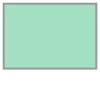

In [40]:
PLACE_NAME = "Lewisham, London, UK"
DATES = "2024-01"

# create geodataframe of place
area = osmnx.geocode_to_gdf(PLACE_NAME)
area = area.to_crs(epsg=4326)

# save geometry of the place
geometry = area.iloc[0].geometry
geometry_json = area.iloc[0].geometry.__geo_interface__
geometry_bounds = geometry.bounds
geometry_bbox = box(geometry_bounds[0], geometry_bounds[1], geometry_bounds[2], geometry_bounds[3])
geometry_bbox_json = geometry_bbox.__geo_interface__

# Download data with land use tagged
land_use = osmnx.features_from_bbox(
    geometry_bounds,
    {"landuse": True},
)

geometry_bbox

### Download Sentinel data for Lewisham
using the below link
https://medium.com/rotten-grapes/download-sentinel-data-within-seconds-in-python-8cc9a8c3e23c

In [41]:
from pystac_client import Client
from odc.stac import load
import odc.geo

In [42]:
def download_sentinel_data(
        client_url="https://earth-search.aws.element84.com/v1", 
        collection="sentinel-2-l2a", 
        geometry=None,
        date=None,
        max_cloud_cover=1
        ):
    # create client
    client = Client.open(client_url)

    # create query parameters
    filters = {
    "eo:cloud_cover":{"lt":max_cloud_cover}
    }

    # execute client search date can be single day, month or range
    # range = yyyy-mm-dd/yyyy-mm-dd (from_Date/to_date)
    search = client.search(
    collections=[collection], intersects=geometry_bbox_json, datetime=date, query=filters
    )

    # loop through each item
    for item in search.items_as_dicts():
        print(item)

    #load the data in xarray format
    data = load(search.items() ,geopolygon=geometry,groupby="solar_day", chunks={})

    return data

sentinel_array = download_sentinel_data(geometry=geometry, date=DATES, max_cloud_cover=0.1)

{'type': 'Feature', 'stac_version': '1.0.0', 'id': 'S2A_30UYB_20240126_0_L2A', 'properties': {'created': '2024-01-26T17:25:08.958Z', 'platform': 'sentinel-2a', 'constellation': 'sentinel-2', 'instruments': ['msi'], 'eo:cloud_cover': 0.076635, 'proj:epsg': 32630, 'mgrs:utm_zone': 30, 'mgrs:latitude_band': 'U', 'mgrs:grid_square': 'YB', 'grid:code': 'MGRS-30UYB', 'view:sun_azimuth': 166.707760901859, 'view:sun_elevation': 19.355038816153495, 's2:degraded_msi_data_percentage': 0.0277, 's2:nodata_pixel_percentage': 20.806988, 's2:saturated_defective_pixel_percentage': 0, 's2:dark_features_percentage': 0.525647, 's2:cloud_shadow_percentage': 0.034752, 's2:vegetation_percentage': 39.588571, 's2:not_vegetated_percentage': 17.895079, 's2:water_percentage': 41.851535, 's2:unclassified_percentage': 0.004717, 's2:medium_proba_clouds_percentage': 0.004818, 's2:high_proba_clouds_percentage': 0.000654, 's2:thin_cirrus_percentage': 0.071164, 's2:snow_ice_percentage': 0.023068, 's2:product_type': 'S2M

In [43]:
print(sentinel_array)

<xarray.Dataset>
Dimensions:       (y: 886, x: 796, time: 1)
Coordinates:
  * y             (y) float64 5.709e+06 5.709e+06 5.709e+06 ... 5.7e+06 5.7e+06
  * x             (x) float64 7.033e+05 7.033e+05 ... 7.113e+05 7.113e+05
    spatial_ref   int32 32630
  * time          (time) datetime64[ns] 2024-01-26T11:16:38.904000
Data variables: (12/32)
    aot           (time, y, x) uint16 dask.array<chunksize=(1, 886, 796), meta=np.ndarray>
    blue          (time, y, x) uint16 dask.array<chunksize=(1, 886, 796), meta=np.ndarray>
    coastal       (time, y, x) uint16 dask.array<chunksize=(1, 886, 796), meta=np.ndarray>
    green         (time, y, x) uint16 dask.array<chunksize=(1, 886, 796), meta=np.ndarray>
    nir           (time, y, x) uint16 dask.array<chunksize=(1, 886, 796), meta=np.ndarray>
    nir08         (time, y, x) uint16 dask.array<chunksize=(1, 886, 796), meta=np.ndarray>
    ...            ...
    rededge3-jp2  (time, y, x) uint16 dask.array<chunksize=(1, 886, 796), meta=np.

In [44]:
print(sentinel_array.coords)


Coordinates:
  * y            (y) float64 5.709e+06 5.709e+06 5.709e+06 ... 5.7e+06 5.7e+06
  * x            (x) float64 7.033e+05 7.033e+05 ... 7.113e+05 7.113e+05
    spatial_ref  int32 32630
  * time         (time) datetime64[ns] 2024-01-26T11:16:38.904000


In [45]:
# Keep only the main spectral bands
public_bands = ["aot", "blue", "coastal", "green", "nir", "red"]
sentinel_filtered = sentinel_array[public_bands]

# keep only the first day
sentinel_filtered = sentinel_filtered.isel(time=0)

In [46]:
sentinel_filtered.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / UTM zone 30N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32630"]]')

In [47]:
sentinel_filtered.head()

<xarray.Dataset>
Dimensions:      (y: 5, x: 5)
Coordinates:
  * y            (y) float64 5.709e+06 5.709e+06 5.709e+06 5.709e+06 5.709e+06
  * x            (x) float64 7.033e+05 7.033e+05 7.033e+05 7.034e+05 7.034e+05
    spatial_ref  int32 32630
    time         datetime64[ns] 2024-01-26T11:16:38.904000
Data variables:
    aot          (y, x) uint16 dask.array<chunksize=(5, 5), meta=np.ndarray>
    blue         (y, x) uint16 dask.array<chunksize=(5, 5), meta=np.ndarray>
    coastal      (y, x) uint16 dask.array<chunksize=(5, 5), meta=np.ndarray>
    green        (y, x) uint16 dask.array<chunksize=(5, 5), meta=np.ndarray>
    nir          (y, x) uint16 dask.array<chunksize=(5, 5), meta=np.ndarray>
    red          (y, x) uint16 dask.array<chunksize=(5, 5), meta=np.ndarray>

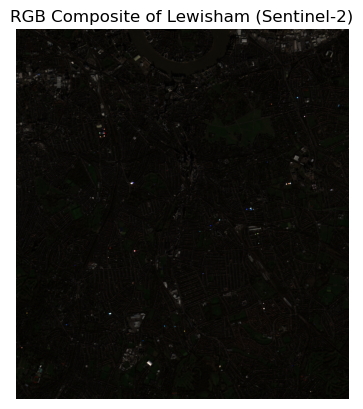

In [48]:
import matplotlib.pyplot as plt

# clip data to remove outliers
red = np.clip(sentinel_filtered['red']/10000,0,1)
green = np.clip(sentinel_filtered['green']/10000,0,1)
blue = np.clip(sentinel_filtered['blue']/10000,0,1)

# Stack the bands together to create an RGB composite
rgb_image = np.dstack((red.values, green.values, blue.values))

# Normalize the image values between 0 and 1 by dividing by the max value
rgb_image = rgb_image / np.max(rgb_image)


# Plot the RGB composite image
plt.imshow(rgb_image)
plt.title("RGB Composite of Lewisham (Sentinel-2)")
plt.axis('off')  # Hide the axis for better visualization
plt.show()

Check both datasets are the same crs

In [49]:
land_use = land_use.to_crs(sentinel_filtered.rio.crs)
assert sentinel_filtered.rio.crs == land_use.crs, f"not the same crs {sentinel_filtered.rio.crs} != {land_use.crs}"

rasterize land use polygons to match sentinel data so each pixel gets a land use

<Axes: >

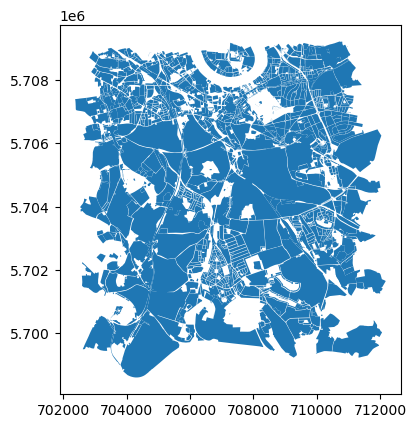

In [50]:
land_use.plot()

In [51]:
land_use.head()

geometry addr:housenumber  \
element id                                                             
node    8629832511    POINT (707017.19 5703589.438)               27   
        9456786573   POINT (710489.441 5708597.324)              NaN   
        11101624091  POINT (707807.504 5704738.035)              NaN   
        12724103392  POINT (707271.581 5707164.818)              NaN   
        12925609365    POINT (710288.28 5708724.95)               51   

                              addr:street addr:suburb  check_date  \
element id                                                          
node    8629832511       Catford Broadway     Catford  2023-07-26   
        9456786573                    NaN         NaN         NaN   
        11101624091                   NaN         NaN         NaN   
        12724103392                   NaN         NaN         NaN   
        12925609365  Anchor And Hope Lane    Charlton         NaN   

                    currency:GBP     landuse level  \
element id                                           
node    8629832511           yes  industrial     0   
        9456786573           NaN  industrial   NaN   
        11101624091          NaN  industrial   NaN   
        12724103392          NaN      retail   NaN   
        12925609365          NaN  commercial   NaN   

                                            name      old_name  ... wall  \
element id                                                      ...        
node    8629832511      K Ali Butchers & Grocers  Nubian Store  ...  NaN   
        9456786573   Charlton Gate Business Park           NaN  ...  NaN   
        11101624091         Lewisham Scrap Metal           NaN  ...  NaN   
        12724103392                Vintners Yard           NaN  ...  NaN   
        12925609365        Duc Tien Cash & Carry           NaN  ...  NaN   

                    verge landcover name:signed pumping_station opening_date  \
element id                                                                     
node    8629832511    NaN       NaN         NaN             NaN          NaN   
        9456786573    NaN       NaN         NaN             NaN          NaN   
        11101624091   NaN       NaN         NaN             NaN          NaN   
        12724103392   NaN       NaN         NaN             NaN          NaN   
        12925609365   NaN       NaN         NaN             NaN          NaN   

                    source:addr layer notes type  
element id                                        
node    8629832511          NaN   NaN   NaN  NaN  
        9456786573          NaN   NaN   NaN  NaN  
        11101624091         NaN   NaN   NaN  NaN  
        12724103392         NaN   NaN   NaN  NaN  
        12925609365         NaN   NaN   NaN  NaN  

[5 rows x 162 columns]

### Create labels and rasterize landuse data

In [52]:
# Get unique land uses
unique_landuses = land_use['landuse'].unique()

# Make mapping
landuse_to_code = {lu: i+1 for i, lu in enumerate(unique_landuses)}  # +1 so 0 can be background

# Reverse mapping (for later decoding)
code_to_landuse = {v: k for k, v in landuse_to_code.items()}

# Add numeric code column
land_use['landuse_code'] = land_use['landuse'].map(landuse_to_code)

In [53]:
land_use.head()

geometry addr:housenumber  \
element id                                                             
node    8629832511    POINT (707017.19 5703589.438)               27   
        9456786573   POINT (710489.441 5708597.324)              NaN   
        11101624091  POINT (707807.504 5704738.035)              NaN   
        12724103392  POINT (707271.581 5707164.818)              NaN   
        12925609365    POINT (710288.28 5708724.95)               51   

                              addr:street addr:suburb  check_date  \
element id                                                          
node    8629832511       Catford Broadway     Catford  2023-07-26   
        9456786573                    NaN         NaN         NaN   
        11101624091                   NaN         NaN         NaN   
        12724103392                   NaN         NaN         NaN   
        12925609365  Anchor And Hope Lane    Charlton         NaN   

                    currency:GBP     landuse level  \
element id                                           
node    8629832511           yes  industrial     0   
        9456786573           NaN  industrial   NaN   
        11101624091          NaN  industrial   NaN   
        12724103392          NaN      retail   NaN   
        12925609365          NaN  commercial   NaN   

                                            name      old_name  ... verge  \
element id                                                      ...         
node    8629832511      K Ali Butchers & Grocers  Nubian Store  ...   NaN   
        9456786573   Charlton Gate Business Park           NaN  ...   NaN   
        11101624091         Lewisham Scrap Metal           NaN  ...   NaN   
        12724103392                Vintners Yard           NaN  ...   NaN   
        12925609365        Duc Tien Cash & Carry           NaN  ...   NaN   

                    landcover name:signed pumping_station opening_date  \
element id                                                               
node    8629832511        NaN         NaN             NaN          NaN   
        9456786573        NaN         NaN             NaN          NaN   
        11101624091       NaN         NaN             NaN          NaN   
        12724103392       NaN         NaN             NaN          NaN   
        12925609365       NaN         NaN             NaN          NaN   

                    source:addr layer notes type landuse_code  
element id                                                     
node    8629832511          NaN   NaN   NaN  NaN            1  
        9456786573          NaN   NaN   NaN  NaN            1  
        11101624091         NaN   NaN   NaN  NaN            1  
        12724103392         NaN   NaN   NaN  NaN            2  
        12925609365         NaN   NaN   NaN  NaN            3  

[5 rows x 163 columns]

In [54]:
import rasterio

# Create an empty array matching sentinel shape
shape = (sentinel_filtered.dims['y'], sentinel_filtered.dims['x'])
transform = sentinel_filtered.rio.transform()

# Create a generator of (geometry, value) tuples
shapes = ((geom, value) for geom, value in zip(land_use.geometry, land_use['landuse_code']))

# Rasterize the landuse data
landuse_raster = rasterio.features.rasterize(
    shapes=shapes,
    out_shape=shape,
    transform=transform,
    fill=0,  # background code (e.g. no data)
    all_touched=True,
    dtype=np.uint8
)

#Check for matching shape
assert landuse_raster.shape == sentinel_filtered['red'].shape, "arrays not the same shape"

note the all_touched will just mean any pixel touched by the polygon will take it on. There is no way compile these if there is overlap using rasterio. So this will just take the LAST polygon that is processed so order matters here.

In [55]:
import pandas as pd
import geopandas as gpd

values, counts = np.unique(landuse_raster, return_counts=True)

mapper = np.vectorize(code_to_landuse.get)
mapped_labels = mapper(values)
land_use_counts = pd.DataFrame({"land_use": mapped_labels, "count": counts})
land_use_counts.sort_values("count", ascending=False)


,land_use,count
5,residential,443044
0,None,136423
4,grass,28977
2,retail,20071
1,industrial,16976
7,recreation_ground,16246
14,railway,11803
9,cemetery,9998
6,construction,5967
10,allotments,4918


### Create patches from the landuse data to make it more manageable

In [56]:
from scipy import stats

patch_size = 8

# Example shapes
height, width = landuse_raster.shape
n_patches_y = height // patch_size
n_patches_x = width // patch_size

n_samples = n_patches_x * n_patches_y
n_sentinel_bands = len(sentinel_filtered.data_vars)

# Crop rasters to be divisible by patch size
crop_height = (landuse_raster.shape[0] // patch_size) * patch_size
crop_width = (landuse_raster.shape[1] // patch_size) * patch_size

landuse_cropped = landuse_raster[:crop_height, :crop_width]
sentinel_cropped = sentinel_filtered.isel(
    y=slice(0, crop_height),
    x=slice(0, crop_width)
).to_array().values

# Reshape to (num_patches_y, patch_size, num_patches_x, patch_size)
# Then swap axes to get (num_patches_y, num_patches_x, patch_size, patch_size)
landuse_patches = landuse_cropped.reshape(n_patches_y, patch_size, n_patches_x, patch_size)
landuse_patches = landuse_patches.transpose(0, 2, 1, 3)

sentinel_patches = np.moveaxis(sentinel_cropped,0,-1)
sentinel_patches = sentinel_patches.reshape(n_patches_y, patch_size, n_patches_x, patch_size, n_sentinel_bands)
sentinel_patches = sentinel_patches.transpose(0, 2, 4, 1, 3)

# Flatten last two dims: (num_patches_y, num_patches_x, patch_size*patch_size)
landuse_patches_flat = landuse_patches.reshape(n_patches_y, n_patches_x, -1)
sentinel_patches_flat = sentinel_patches.reshape(n_patches_y, n_patches_x, n_sentinel_bands, -1)

print(landuse_cropped.shape)
print(sentinel_cropped.shape)
print(landuse_patches_flat.shape)
print(sentinel_patches_flat.shape)


(880, 792)
(6, 880, 792)
(110, 99, 64)
(110, 99, 6, 64)


### Compute the appropraite functions on the flattened patches
- landuse you want mode
- lets compute median for sentinel (could add more for this)

In [57]:
# Compute mode (most common label) along the flattened patch axis
mode_result = stats.mode(landuse_patches_flat, axis=2, keepdims=False)
majority_labels = mode_result.mode  # shape: (num_patches_y, num_patches_x)

# Compute median (middle label) along the flattened patch axis
median_score = np.median(sentinel_patches_flat, axis=3, keepdims=False)
mean_score = np.mean(sentinel_patches_flat, axis=3, keepdims=False)
std_score = np.std(sentinel_patches_flat, axis=3, keepdims=False)

# Stack along last axis (features)
features = np.concatenate(
    [mean_score, std_score, median_score], axis=2
)  # shape: (n_patches_y, n_patches_x, n_sentinel_bands * 3)

print(majority_labels.shape)
print(features.shape)

(110, 99)
(110, 99, 18)


### Add purity mask for later weightings

In [58]:
high_purity_threshold = 0.9
low_purity_threshold = 0.3
patch_area = patch_size * patch_size
purity_mask = np.where((mode_result.count / patch_area) >= high_purity_threshold, 3,
          np.where((mode_result.count / patch_area) >= low_purity_threshold, 2, 1))
purity_mask

array([[3, 3, 3, ..., 2, 3, 3],
       [2, 3, 2, ..., 2, 3, 3],
       [2, 2, 2, ..., 3, 3, 3],
       ...,
       [3, 2, 2, ..., 3, 3, 3],
       [3, 2, 2, ..., 3, 3, 3],
       [3, 3, 2, ..., 3, 2, 2]])

### Reshape to 1D array for use by ML

In [106]:
landuse_vector = majority_labels.reshape(n_samples)
purity_mask_vector = purity_mask.reshape(n_samples)
sentinel_vector = features.reshape(n_samples, -1)

print(landuse_vector.shape)
print(purity_mask_vector.shape)
print(sentinel_vector.shape)

(10890,)
(10890,)
(10890, 18)


## Move onto creating ML pipeline

In [107]:
import torch
from sklearn.model_selection import train_test_split 

### Split data for test and train

In [108]:
X = sentinel_vector
y = landuse_vector
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)
X_train, X_eval, y_train, y_eval = train_test_split(
    X_train, y_train, test_size=0.2, random_state=1)

In [109]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer

X_preprocessing_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    MinMaxScaler()
)

Y_preprocessing_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    MinMaxScaler()
)

X_train__p = X_preprocessing_pipeline.fit_transform(X_train)
X_eval__p = X_preprocessing_pipeline.transform(X_eval)
X_test__p = X_preprocessing_pipeline.transform(X_test)

In [110]:
X_train__t = torch.tensor(X_train__p, dtype=torch.float32)
y_train__t = torch.tensor(y_train, dtype=torch.float32)
X_eval__t = torch.tensor(X_eval__p, dtype=torch.float32)
y_eval__t = torch.tensor(y_eval, dtype=torch.float32)

In [111]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train__t, y_train__t)
loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [142]:
import torch.nn as nn

class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size[0])
        self.layer2 = nn.Linear(hidden_size[0], hidden_size[1])  
        self.layer3 = nn.Linear(hidden_size[1], hidden_size[2]) 
        self.layer4 = nn.Linear(hidden_size[2], output_size) 

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.relu(self.layer3(x))
        x = torch.softmax(self.layer4(x), dim=1)
        return x
    
input_size = X_train__t.shape[1]
hidden_size = [512,256,128]
output_size = int(y_train__t.max().item())+1

model = Model(input_size, hidden_size, output_size)

learning_rate = 0.0001

loss_fn = nn.CrossEntropyLoss()
 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [143]:
num_epochs = 2000
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs
batch_size = 32
train_dl = DataLoader(train_dataset, batch_size, shuffle=True)
log_epochs = 10

for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (pred.argmax(dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
        
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

    if epoch % log_epochs == 0:
        print(f'Epoch {epoch} Loss: {loss_hist[epoch]:.4f}, Accuracy: {accuracy_hist[epoch]:.4f}')

Epoch 0 Loss: 2.8188, Accuracy: 0.5975
Epoch 10 Loss: 2.5873, Accuracy: 0.6599
Epoch 20 Loss: 2.5873, Accuracy: 0.6599
Epoch 30 Loss: 2.5873, Accuracy: 0.6599
Epoch 40 Loss: 2.5873, Accuracy: 0.6599
Epoch 50 Loss: 2.5873, Accuracy: 0.6599
Epoch 60 Loss: 2.5873, Accuracy: 0.6599
Epoch 70 Loss: 2.5873, Accuracy: 0.6599
Epoch 80 Loss: 2.5873, Accuracy: 0.6599


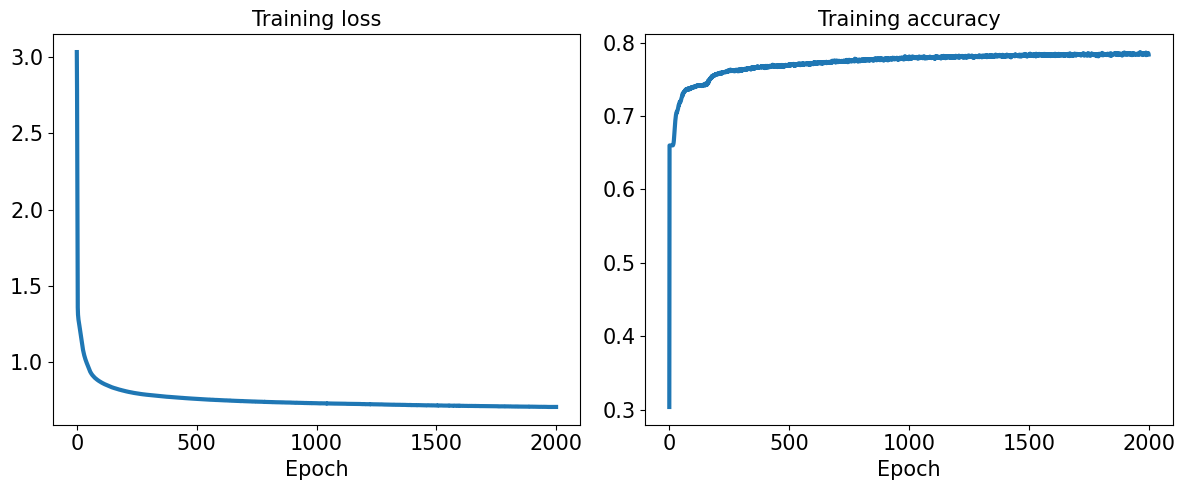

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()

#plt.savefig('figures/12_09.pdf')
 
plt.show()

### Evaluation set

In [ ]:
pred_eval = model(X_eval__t)
is_correct = (pred_eval.argmax(dim=1) == y_eval__t).float()
accuracy = is_correct.mean()  # mean() is simpler than sum()/len
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.7722
